1. Definição do nosso problema

Vamos considerar dois dados de cada pedido:

Feature	O que representa
tempo_espera	tempo de espera estimado para atender o pedido
distancia	distância estimada para realizar o serviço

A saída será:

+1 → baixo risco de cancelamento
-1 → alto risco de cancelamento

Para o primeiro teste, vamos trabalhar com dados simulados, assim como o professor fez no exemplo da fintech. Depois podemos substituir por dados reais do Collect Express.

In [1]:
!pip install pennylane matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 94.1 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


In [2]:
import pennylane as qml
import pennylane.numpy as np
import matplotlib.pyplot as plt

In [3]:
# Dados simulados do Collect Express
# [tempo de espera normalizado, distância normalizada]

X_dados = np.array([
    [0.1, 0.2],
    [0.2, 0.1],
    [0.3, 0.2],

    [0.7, 0.8],
    [0.8, 0.7],
    [0.9, 0.9]
], requires_grad=False)

# Rótulos
# +1 = baixo risco de cancelamento
# -1 = alto risco de cancelamento

Y_rotulos = np.array([
     1,  1,  1,
    -1, -1, -1
], requires_grad=False)

Podemos interpretar, de forma simplificada:

[0.1, 0.2]
 ↓
pouca espera + pouca distância
 ↓
baixo risco

e:

[0.8, 0.7]
 ↓
muita espera + grande distância
 ↓
alto risco

In [4]:
dev = qml.device("default.qubit", wires=2)

wires=1

wires=2

In [5]:
@qml.qnode(dev)
def vqc_circuito(pesos_treinaveis, x_features):

    # --------------------------------
    # A) ENTRADA DOS DADOS
    # --------------------------------

    # Tempo de espera -> qubit 0
    qml.RX(x_features[0], wires=0)

    # Distância -> qubit 1
    qml.RY(x_features[1], wires=1)

    # --------------------------------
    # B) CAMADA VARIACIONAL
    # --------------------------------

    qml.Rot(*pesos_treinaveis[0], wires=0)
    qml.Rot(*pesos_treinaveis[1], wires=1)

    # --------------------------------
    # C) EMARANHAMENTO
    # --------------------------------

    qml.CNOT(wires=[0, 1])

    # --------------------------------
    # D) SEGUNDA CAMADA
    # --------------------------------

    qml.Rot(*pesos_treinaveis[2], wires=0)
    qml.Rot(*pesos_treinaveis[3], wires=1)

    # --------------------------------
    # E) MEDIÇÃO
    # --------------------------------

    return qml.expval(qml.PauliZ(1))

O que acontece aqui?

Visualmente:

         PEDIDO COLLECT EXPRESS
                 │
        ┌────────┴────────┐
        │                 │
 Tempo de espera      Distância
        │                 │
       RX                RY
        │                 │
     QUBIT 0          QUBIT 1
        │                 │
        └────── CNOT ─────┘
              │
        EMARANHAMENTO
              │
       Rotações ajustáveis
              │
           PauliZ
              │
        Resultado final

Os dois dados entram separadamente nos dois qubits e, depois, o CNOT cria uma relação entre eles.

In [7]:
def custo_classificador(pesos, X, Y):

    perdas = [
        (vqc_circuito(pesos, x) - y) ** 2
        for x, y in zip(X, Y)
    ]

    return qml.math.mean(qml.math.stack(perdas))



In [9]:
np.random.seed(42)

pesos_iniciais = np.random.random((4, 3), requires_grad=True)

opt = qml.GradientDescentOptimizer(stepsize=0.4)

In [10]:
pesos_otimizados = pesos_iniciais

print("=== INICIANDO O TREINAMENTO DO VQC ===")

historico_custo = []

for epoca in range(15):

    pesos_otimizados, custo_val = opt.step_and_cost(
        lambda p: custo_classificador(
            p,
            X_dados,
            Y_rotulos
        ),
        pesos_otimizados
    )

    historico_custo.append(custo_val)

    if epoca % 3 == 0 or epoca == 14:
        print(
            f"Época {epoca:2d} | "
            f"Custo (Erro): {custo_val:.4f}"
        )

=== INICIANDO O TREINAMENTO DO VQC ===
Época  0 | Custo (Erro): 0.7482
Época  3 | Custo (Erro): 0.5660
Época  6 | Custo (Erro): 0.4754
Época  9 | Custo (Erro): 0.4206
Época 12 | Custo (Erro): 0.3889
Época 14 | Custo (Erro): 0.3763


Aqui acontece o aprendizado.

A cada época:

parâmetros atuais
       ↓
executa circuito
       ↓
calcula resultado
       ↓
compara com o rótulo
       ↓
calcula erro
       ↓
Gradient Descent
       ↓
ajusta os parâmetros

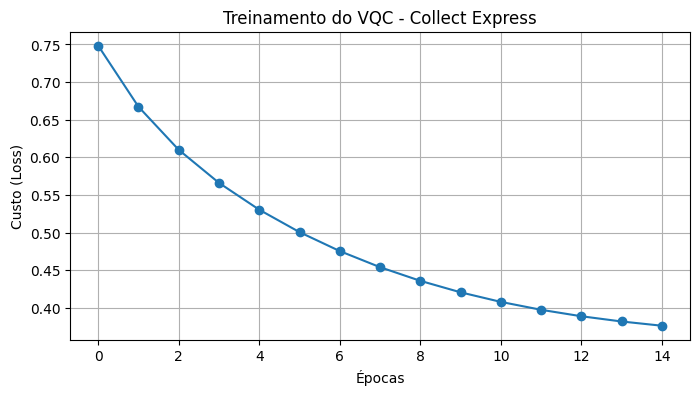

In [11]:
plt.figure(figsize=(8, 4))

plt.plot(
    historico_custo,
    marker='o'
)

plt.title("Treinamento do VQC - Collect Express")
plt.xlabel("Épocas")
plt.ylabel("Custo (Loss)")
plt.grid(True)

plt.show()

Testar um novo pedido

In [12]:
# Novo pedido
# [tempo de espera, distância]

novo_pedido = np.array(
    [0.8, 0.7],
    requires_grad=False
)

resultado = vqc_circuito(
    pesos_otimizados,
    novo_pedido
)

if resultado > 0:
    classe_prevista = "BAIXO RISCO DE CANCELAMENTO"
else:
    classe_prevista = "ALTO RISCO DE CANCELAMENTO"

print("\n=== NOVO PEDIDO ===")
print(f"Tempo de espera: {novo_pedido[0]}")
print(f"Distância: {novo_pedido[1]}")
print(f"Saída do circuito: {resultado:.4f}")
print(f"Classificação: {classe_prevista}")


=== NOVO PEDIDO ===
Tempo de espera: 0.8
Distância: 0.7
Saída do circuito: -0.3184
Classificação: ALTO RISCO DE CANCELAMENTO


O que o projeto está fazendo?

No final, o fluxo fica:

                 COLLECT EXPRESS
                       │
                       ▼
                Dados do pedido
                       │
              ┌────────┴────────┐
              ▼                 ▼
        Tempo de espera      Distância
              │                 │
              ▼                 ▼
             RX                RY
              │                 │
             Q0                Q1
              └────────┬────────┘
                       ▼
                     CNOT
                       │
                EMARANHAMENTO
                       │
                       ▼
              Circuito variacional
                       │
                       ▼
                  Treinamento
                       │
                 Gradient Descent
                       │
                       ▼
                 Medição PauliZ
                       │
                       ▼
                ┌──────────────┐
                │ Classificação│
                └──────┬───────┘
                       │
             ┌─────────┴─────────┐
             ▼                   ▼
       Baixo risco           Alto risco
       cancelamento          cancelamento